<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: \'Helvetica\', sans-serif; margin-bottom: 5px;">MAT1610: Cálculo I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 06: Recta Tangente y Aproximación Local</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> XXX | <b>Fecha:</b> XX de XXX, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>
</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contexto y Referencias</h3>
    <p>En ingeniería, rara vez trabajamos con modelos matemáticos perfectos y manejables. Muchas veces nos encontramos con funciones trascendentes o datos experimentales no lineales. Una estrategia fundamental del cálculo es reemplazar funciones complicadas por aproximaciones más simples (generalmente polinomios) cerca de un punto de interés. Este laboratorio aborda la <b>aproximación lineal</b> (usando la recta tangente) y su generalización, los <b>polinomios de Taylor</b>. (<i>Referencia: Stewart, Cálculo de una variable, Capítulos 3.10 y 11.11</i>).</p>
</div>

<div style="display: flex; gap: 20px;">
    <div style="flex: 1; border: 1px solid #27ae60; border-left: 8px solid #27ae60; padding: 15px; border-radius: 5px;">
        <h3 style="color: #27ae60; margin-top: 0;">Contenidos</h3>
        <ol>
            <li>Aproximación por Recta Tangente (Linealización).</li>
            <li>Polinomios de Taylor y Maclaurin.</li>
            <li>Análisis Local y Medición del Error.</li>
        </ol>
    </div>
    <div style="flex: 1; border: 1px solid #f39c12; border-left: 8px solid #f39c12; padding: 15px; border-radius: 5px;">
        <h3 style="color: #f39c12; margin-top: 0;">Objetivos de Aprendizaje</h3>
        <ul>
            <li>Calcular la recta tangente simbólicamente usando <code>SymPy</code>.</li>
            <li>Implementar series de Taylor para aproximar curvas complejas.</li>
            <li>Visualizar convergencias y medir tolerancias de error con <code>Matplotlib</code> y <code>Pandas</code>.</li>
        </ul>
    </div>
</div>

In [1]:
# Importar librerías de la sesión
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ipywidgets import interact, widgets

# Configuración para visualización matemática y gráficas
sp.init_printing()
%matplotlib inline

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except:
    plt.style.use("seaborn-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# **1. Aproximación por Recta Tangente (Linealización)**

La intuición geométrica de la derivada nos dice que si hacemos suficiente "zoom" sobre el gráfico de una función derivable en un punto $a$, la curva luce casi indistinguible de su **recta tangente** en ese punto. 

A esta recta la llamamos la **aproximación lineal** o **linealización** de $f$ en $a$, denotada por $L(x)$:
$$L(x) = f(a) + f\'(a)(x - a)$$

Para valores de $x$ cercanos a $a$, tenemos que $f(x) \approx L(x)$. En ingeniería, esto nos permite simplificar ecuaciones de modelos físicos no lineales asumiendo pequeñas perturbaciones alrededor de un punto de operación.

### Ejemplo 1.1: Cálculo Simbólico de la Linealización
Encuentre la aproximación lineal de la función de esfuerzo-deformación simplificada $f(x) = \ln(1 + x)$ cerca de $x = 0$ utilizando `SymPy`.

In [2]:
# Definimos el símbolo y la función
x = sp.Symbol("x")
f = sp.log(1 + x)
a = 0  # Punto de aproximación

# Evaluamos f(a) y la derivada f\'(a)
f_a = f.subs(x, a)
df_a = sp.diff(f, x).subs(x, a)

# Construimos la recta tangente L(x)
L = f_a + df_a * (x - a)

print("Función original f(x):")
display(f)
print("Aproximación Lineal L(x) alrededor de a=0:")
display(L)

Función original f(x):


Aproximación Lineal L(x) alrededor de a=0:


### Ejemplo 1.2: Visualización Geométrica de la Tangente
Grafique la función $f(x) = \ln(1 + x)$ y su aproximación lineal $L(x)$ en el intervalo $[-0.5, 2]$ para visualizar el concepto de aproximación local.

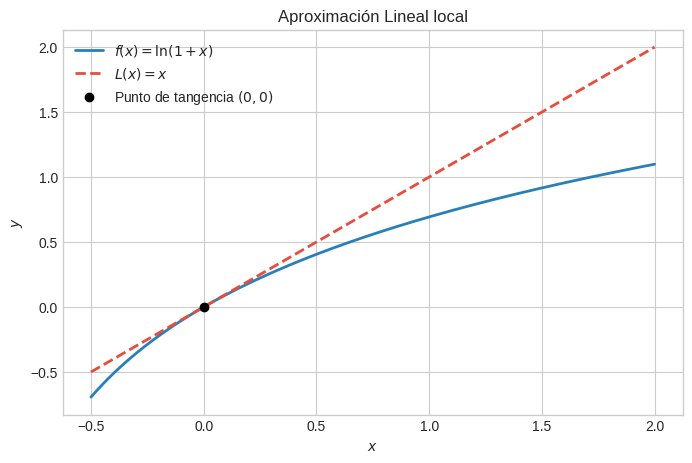

In [3]:
# Convertimos expresiones de SymPy a funciones numéricas de NumPy
f_num = sp.lambdify(x, f, "numpy")
L_num = sp.lambdify(x, L, "numpy")

# Dominio de graficación
x_vals = np.linspace(-0.5, 2, 200)

plt.figure()
# Graficamos la función
plt.plot(x_vals, f_num(x_vals), label=r"$f(x) = \ln(1+x)$", color="#2980b9", lw=2)
# Graficamos la recta tangente
plt.plot(x_vals, L_num(x_vals), label=r"$L(x) = x$", color="#e74c3c", linestyle="--", lw=2)
# Destacamos el punto de tangencia
plt.scatter([0], [0], color="black", zorder=5, label="Punto de tangencia $(0,0)$")

plt.title("Aproximación Lineal local")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()

### Ejemplo 1.3: Aproximación Práctica en Circuitos (Pandas)
El voltaje de descarga de un capacitor está dado por $V(t) = 12 e^{-0.5t}$. Comparemos numéricamente la función real contra su linealización en $t=0$ construyendo una tabla con `Pandas`.

In [4]:
t = sp.Symbol("t")
V = 12 * sp.exp(-0.5 * t)
V_L = V.subs(t, 0) + sp.diff(V, t).subs(t, 0) * (t - 0)

# Convertimos a funciones numéricas
V_num = sp.lambdify(t, V, "numpy")
VL_num = sp.lambdify(t, V_L, "numpy")

# Puntos a evaluar (alejándonos de 0)
t_eval = np.array([0, 0.1, 0.2, 0.5, 1.0])
real_vals = V_num(t_eval)
lin_vals = VL_num(t_eval)

# Construimos DataFrame para comparar
df_comp = pd.DataFrame({
    "Tiempo t (s)": t_eval,
    "Voltaje Real V(t)": real_vals,
    "Aproximación L(t)": lin_vals,
    "Error Absoluto": np.abs(real_vals - lin_vals)
})

display(df_comp)
# Observamos cómo el error crece considerablemente a medida que t se aleja de 0.

,Tiempo t (s),Voltaje Real V(t),Aproximación L(t),Error Absoluto
0,0.0,12.000000,12.0,0.000000
1,0.1,11.414753,11.4,0.014753
2,0.2,10.858049,10.8,0.058049
3,0.5,9.345609,9.0,0.345609
4,1.0,7.278368,6.0,1.278368


# **2. Polinomios de Taylor y Maclaurin**

Si la recta tangente es la mejor aproximación lineal, ¿no sería posible utilizar una parábola para obtener una mejor aproximación? ¿O un polinomio de grado 3?

El **Polinomio de Taylor de grado $n$** de $f(x)$ centrado en $x=a$ agrega curvaturas progresivas para ajustarse mejor a la función. Su fórmula es:
$$T_n(x) = f(a) + \frac{f\'(a)}{1!}(x-a) + \frac{f\'\'(a)}{2!}(x-a)^2 + \cdots + \frac{f^{(n)}(a)}{n!}(x-a)^n = \sum_{k=0}^{n} \frac{f^{(k)}(a)}{k!} (x-a)^k$$

*(Si $a=0$, se le conoce históricamente como polinomio de Maclaurin).*

### Ejemplo 2.1: Cálculo con `sympy.series`
En lugar de calcular derivadas a mano repetitivamente, `SymPy` posee la poderosa función `.series()` para calcular expansiones de Taylor. Aproxime $f(x) = \sin(x)$ con polinomios de grado 1, 3 y 5 centrados en $x=0$.

In [5]:
f2 = sp.sin(x)

# El parámetro de profundidad "n" en series() corta el término en O(x^n)
# Usamos .removeO() para eliminar la notación asintótica "O"
T1 = f2.series(x, 0, 2).removeO() # Grado 1 (hasta x^1)
T3 = f2.series(x, 0, 4).removeO() # Grado 3 (hasta x^3)
T5 = f2.series(x, 0, 6).removeO() # Grado 5 (hasta x^5)

print("T_1(x) = "); display(T1)
print("T_3(x) = "); display(T3)
print("T_5(x) = "); display(T5)

T_1(x) = 


T_3(x) = 


T_5(x) = 


### Ejemplo 2.2: Visualizando el Efecto de "Abrazo"
Grafiquemos la función seno y sus polinomios de Taylor $T_1$, $T_3$ y $T_5$ para ver cómo a mayor grado, el polinomio "abraza" a la curva en un dominio más grande.

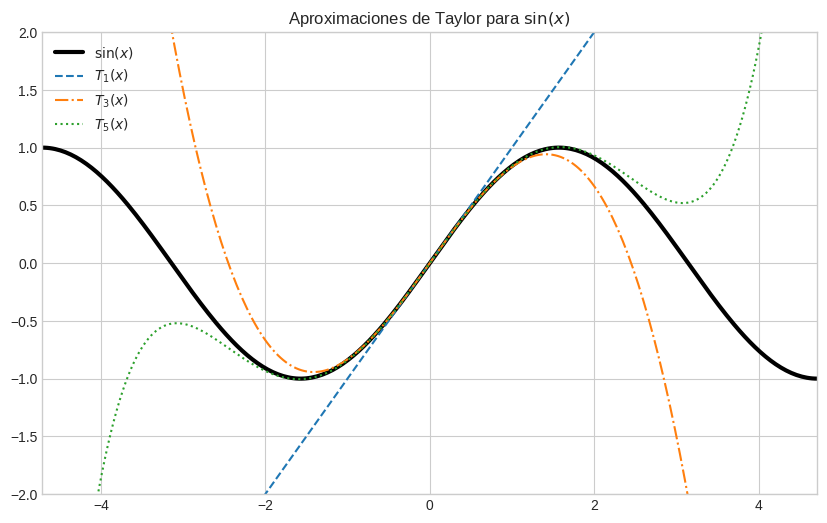

In [6]:
# Funciones lambdify
f2_num = sp.lambdify(x, f2, "numpy")
T1_num = sp.lambdify(x, T1, "numpy")
T3_num = sp.lambdify(x, T3, "numpy")
T5_num = sp.lambdify(x, T5, "numpy")

x_vals = np.linspace(-np.pi*1.5, np.pi*1.5, 300)

plt.figure(figsize=(10,6))
plt.plot(x_vals, f2_num(x_vals), label=r"$\sin(x)$", color="black", lw=3)
plt.plot(x_vals, T1_num(x_vals), label=r"$T_1(x)$", linestyle="--")
plt.plot(x_vals, T3_num(x_vals), label=r"$T_3(x)$", linestyle="-.")
plt.plot(x_vals, T5_num(x_vals), label=r"$T_5(x)$", linestyle=":")

plt.ylim(-2, 2)
plt.xlim(-np.pi*1.5, np.pi*1.5)
plt.title("Aproximaciones de Taylor para $\sin(x)$")
plt.legend()
plt.show()

### Ejemplo 2.3: Aplicación en Integrales Complejas
En óptica de Fresnel, aparece la integral de $\sin(x^2)$, la cual no tiene primitiva elemental. Podemos usar polinomios de Taylor para aproximar la integral definida $\int_0^1 \sin(x^2) dx$.

In [7]:
# Sustituimos x por x^2 en el polinomio T5 de sin(x)
f3 = sp.sin(x**2)
# Calculamos expansión hasta grado 10 (lo que equivale a usar T5 de sin(u))
T_integ = f3.series(x, 0, 11).removeO()

display(sp.Eq(sp.Symbol("T(x)"), T_integ))

# Integramos la aproximación polinomial
integral_aprox = sp.integrate(T_integ, (x, 0, 1))
integral_exacta = sp.integrate(f3, (x, 0, 1)).evalf()

print(f"Valor aproximado de la integral: {integral_aprox:.6f}")
print(f"Valor numérico exacto de la integral: {integral_exacta:.6f}")

Valor aproximado de la integral: 0.310281
Valor numérico exacto de la integral: 0.310268


# **3. Análisis Local y Medición del Error**

Toda aproximación conlleva un error (Resto). Para el diseño en ingeniería, es imperativo garantizar que nuestras simplificaciones no superen un umbral máximo (tolerancia).
El Error Absoluto está dado por:
$$E_n(x) = |f(x) - T_n(x)|$$

En esta sección mediremos visual y computacionalmente el **radio de validez** de nuestra aproximación para una tolerancia dada $\varepsilon$.

### Ejemplo 3.1: Graficando la Función de Error
Encontraremos el polinomio de Maclaurin de grado 2 para $f(x) = e^{-x^2/2}$ (campana de Gauss) y graficaremos el error absoluto cometido al usarlo como aproximación.

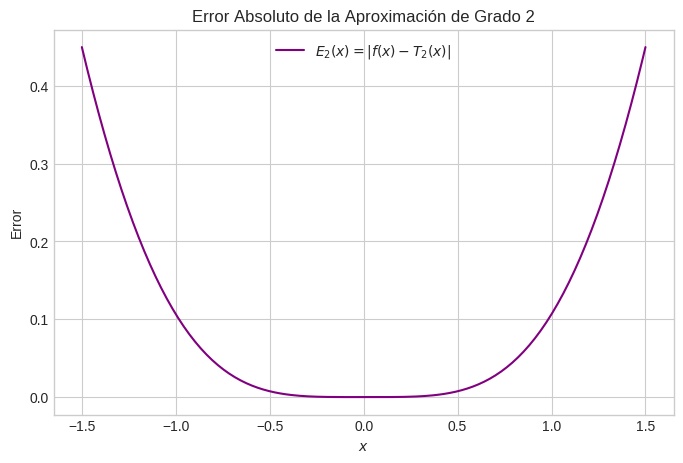

In [8]:
f_gauss = sp.exp(-x**2 / 2)
T2_gauss = f_gauss.series(x, 0, 3).removeO()

# Funciones numéricas para el error
fg_num = sp.lambdify(x, f_gauss, "numpy")
T2g_num = sp.lambdify(x, T2_gauss, "numpy")

x_vals = np.linspace(-1.5, 1.5, 200)
error_vals = np.abs(fg_num(x_vals) - T2g_num(x_vals))

plt.figure()
plt.plot(x_vals, error_vals, color="purple", label=r"$E_2(x) = |f(x) - T_2(x)|$")
plt.title("Error Absoluto de la Aproximación de Grado 2")
plt.xlabel("$x$")
plt.ylabel("Error")
plt.grid(True)
plt.legend()
plt.show()

### Ejemplo 3.2: Determinando el Radio de Validez
Si en nuestro proyecto de ingeniería la tolerancia máxima permitida es $\varepsilon = 0.05$, ¿En qué intervalo $[-R, R]$ podemos utilizar la aproximación $T_2(x)$ en lugar de $e^{-x^2/2}$ con seguridad?

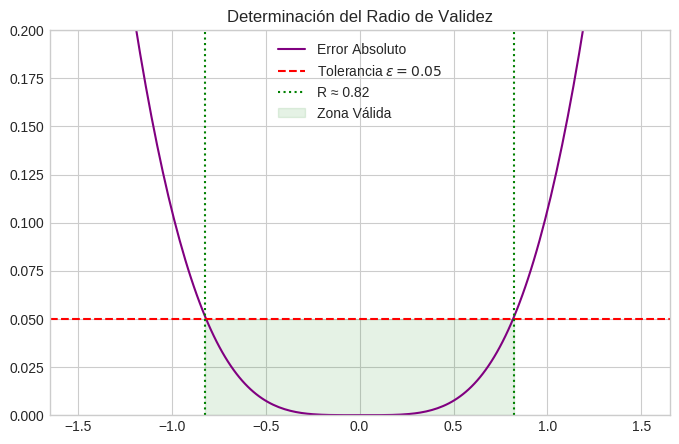

In [14]:
tolerancia = 0.05

plt.figure()
plt.plot(x_vals, error_vals, color="purple", label="Error Absoluto")
plt.axhline(y=tolerancia, color="red", linestyle="--", label=rf"Tolerancia $\varepsilon={tolerancia}$")

# Encuentra iterativamente dónde el error cruza la tolerancia
# Usamos argwhere para buscar el índice
indices_excedidos = np.argwhere(error_vals > tolerancia)

if len(indices_excedidos) > 0:
    # Buscamos el primer valor positivo que excede
    x_positivos = x_vals[indices_excedidos]
    x_limit = x_positivos[x_positivos > 0][0] if len(x_positivos[x_positivos > 0]) > 0 else None
    
    if x_limit:
        # CORRECCIÓN: Aquí formateamos x_limit directamente como escalar (sin el [0])
        plt.axvline(x=x_limit, color="green", linestyle=":", label=f"R ≈ {x_limit:.2f}")
        plt.axvline(x=-x_limit, color="green", linestyle=":")
        plt.fill_between(x_vals, 0, tolerancia, where=(np.abs(x_vals) <= x_limit), color="green", alpha=0.1, label="Zona Válida")

plt.ylim(0, 0.2)
plt.title("Determinación del Radio de Validez")
plt.legend()
plt.show()

### Ejemplo 3.3: Uso de Widgets para interactividad
A continuación crearemos un control deslizante (slider) interactivo utilizando `ipywidgets` que nos permite visualizar instantáneamente cómo cambia la aproximación en $x=0$ a medida que variamos el grado $n$ del Polinomio de Taylor para la función $f(x) = \arctan(x)$ (Esfuerzo de compresión).
*Nota: Ejecuta la celda para activar la herramienta interactiva en el notebook.*

In [10]:
def interact_taylor(grado=1):
    f_arc = sp.atan(x)
    T_n = f_arc.series(x, 0, grado+1).removeO()
    
    f_num = sp.lambdify(x, f_arc, "numpy")
    Tn_num = sp.lambdify(x, T_n, "numpy")
    
    x_ax = np.linspace(-2, 2, 200)
    
    plt.figure(figsize=(8,4))
    plt.plot(x_ax, f_num(x_ax), label=r"$f(x)=\arctan(x)$", color="black", lw=2)
    # Numpy evalua constantes como escalares, se previene con np.ones_like
    y_tn = Tn_num(x_ax)
    if np.isscalar(y_tn): y_tn = y_tn * np.ones_like(x_ax)
    
    plt.plot(x_ax, y_tn, label=f"Taylor $T_{{{grado}}}(x)$", linestyle="--", color="red")
    plt.ylim(-2, 2)
    plt.xlim(-2, 2)
    plt.title(f"Aproximación de Taylor de Grado {grado}")
    plt.legend()
    plt.show()

# Ejecución del widget
# Si está corriendo en un entorno Jupyter activo, se verá un slider.
interact(interact_taylor, grado=widgets.IntSlider(min=1, max=15, step=2, value=1));

interactive(children=(IntSlider(value=1, description='grado', max=15, min=1, step=2), Output()), _dom_classes=…

<div class="alert alert-block alert-success" style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;"> 
    <h2 style="color: #2e7d32; margin-top: 0;">🏁 Ticket de Salida</h2>
    <p style="font-size: 1.1em; color: #1b5e20;"><strong>¡Felicidades!</strong> Hemos llegado al final de los contenidos de este laboratorio. Ahora es tu turno de poner en práctica lo que aprendiste resolviendo los siguientes retos computacionales. Utiliza bloques de código y <code>SymPy</code>/<code>Matplotlib</code> para tus respuestas.</p>
    <h3 style="color: #2e7d32; margin-top: 15px;">💻 Ejercicios: </h3>
</div>

### Ejercicio 1: Aproximación en Deflexión de Vigas
Una carga puntual produce una deflexión en un perfil de acero dada por la función $y(x) = \frac{100}{x^2 + 10}$ donde $x$ es la distancia desde el centro.
1. Encuentre simbólicamente la ecuación de la recta tangente $L(x)$ en el punto $a = 3$.
2. Grafique la curva original $y(x)$ y su recta tangente $L(x)$ en el intervalo $[0, 5]$.

---

In [11]:
# Escriba su código aquí

### Ejercicio 2: Polinomio de Taylor para Expansión Térmica
El coeficiente de una placa por temperatura se modela mediante $C(T) = \sqrt{T^3 + 1}$.
1. Encuentre el polinomio de Taylor de grado 3 de $C(T)$ centrado en el estado basal $a = 2$.
2. Imprima la expresión algebraica resultante.

---

In [12]:
# Escriba su código aquí

### Ejercicio 3: Evaluación de Tolerancia
Deseamos aproximar la función $\cos(x)$ usando su polinomio de Maclaurin de grado 4 ($T_4(x)$).
1. Grafique la función del error absoluto $E(x) = |\cos(x) - T_4(x)|$ en el intervalo $[-2, 2]$.
2. Identifique visualmente e indique mediante un `print()` en qué intervalo aproximado $[-R, R]$ el error es menor estricto a $0.02$.

---

In [ ]:
# Escriba su código aquí

<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Manuel A. Sánchez </strong><br>
        <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT1610 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>